In [161]:
import aim
import matplotlib.pyplot as plt
from plotting_constants import *

In [162]:
import pandas as pd
from aim import Repo
from aim.storage.context import Context

repo = Repo("..")
runs = list(repo.iter_runs())


def get_loss_df(run, subset):
    metric = run.get_metric("loss", context=Context({"subset": subset}))
    if metric is None:
        return pd.DataFrame(columns=["step", "value"])

    df = metric.dataframe()
    if df is None or df.empty:
        return pd.DataFrame(columns=["step", "value"])

    return df[["step", "value"]]


def last_loss_value(df):
    if df is None or df.empty:
        return None
    return float(df["value"].iloc[-1])


train_loss_by_run = {r.hash: get_loss_df(r, "train") for r in runs}
val_loss_by_run = {r.hash: get_loss_df(r, "val") for r in runs}

single_metrics_df = pd.DataFrame([
    {
        "run_hash": r.hash,
        "experiment": r.experiment,
        "learning_rate": (r.get("run_context") or {}).get("learning_rate"),
        "posttraining_validation_loss": r.get("posttraining_validation_loss"),
        "tokens_per_parameter": r.get("tokens_per_parameter"),
        "num_layers": (r.get("run_context") or {}).get("num_layers"),
        "final_train_loss": last_loss_value(train_loss_by_run[r.hash]),
        "final_val_loss": last_loss_value(val_loss_by_run[r.hash]),
    }
    for r in runs
])

single_metrics_df.head()

RepoIntegrityError: Missing props for Run 0fbfee9ce04b42d4b28aeaac

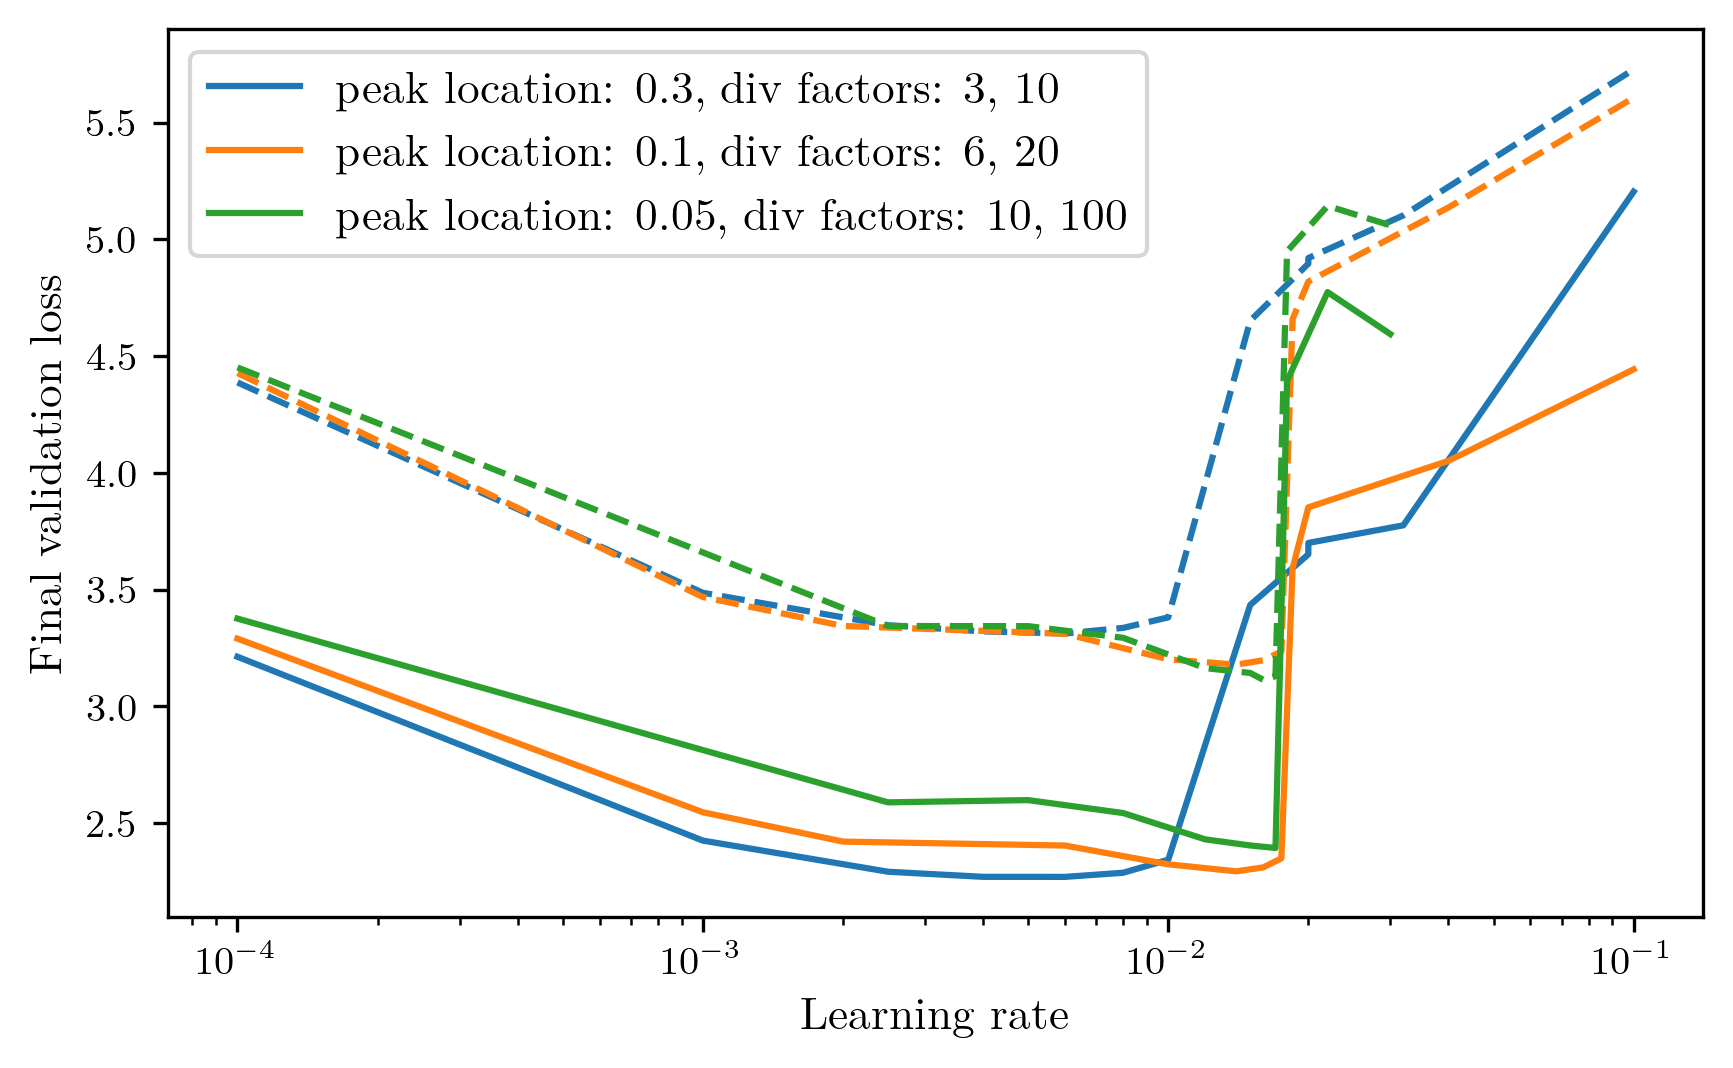

In [129]:
better_name_dict = {"learning_rate_search": "peak location: 0.3, div factors: 3, 10",
                    "learning_rate_search_reduced_pct": "peak location: 0.05, div factors: 10, 100",
                    "learning_rate_search_balanced_pct": "peak location: 0.1, div factors: 6, 20",}

fig, ax = plt.subplots(figsize=big_fig)
for exp, g in single_metrics_df.groupby("experiment"):
    if exp not in better_name_dict.keys():
        continue
    g.sort_values("learning_rate", ascending=True, inplace=True)
    train_line, = ax.plot(g["learning_rate"], g["final_train_loss"], label=better_name_dict[exp])
    ax.plot(g["learning_rate"], g["posttraining_validation_loss"], linestyle="--", color=train_line.get_color())
    
ax.set_xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_rate_sweeps.png")

In [130]:
single_metrics_df[single_metrics_df["experiment"] == "learning_rate_search_balanced_pct"]["run_hash"]

0     025dff3010c4495aa8037895
2     0b75dbb3625c44008ce7a320
9     2484174f94c24a438deb30df
10    27948c29a3ac487e831a1f6a
33    770caacc52d9491ab1c95d6c
42    9260e9f32e184d82b488f89d
48    a6a4da5685e541f0a51e1120
49    a6ad62e5a01e4b5fa41949c1
54    be2b7e5210244ae4907533ac
59    d9f6bb7baf8745f9a46101bc
63    e3179fc2a11e46a1ae01086c
65    f932d08536954459809bef44
Name: run_hash, dtype: object

In [137]:
frames = []
for run_hash in single_metrics_df[single_metrics_df["experiment"] == "learning_rate_search_balanced_pct"]["run_hash"]:
    run_df = val_loss_by_run[run_hash]
    run_df["final_val_loss"] = single_metrics_df[single_metrics_df["run_hash"] == run_hash]["posttraining_validation_loss"].item()
    run_df["learning_rate"] = single_metrics_df[single_metrics_df["run_hash"] == run_hash]["learning_rate"].item()
    frames.append(run_df)
    
runs_df = pd.concat(frames)
runs_df

,step,value,final_val_loss,learning_rate
0,30,49.306580,4.427736,0.0001
1,60,32.919930,4.427736,0.0001
2,90,24.090265,4.427736,0.0001
3,120,19.410635,4.427736,0.0001
4,150,16.551481,4.427736,0.0001
...,...,...,...,...
91,2760,5.133278,4.819520,0.0200
92,2790,5.155673,4.819520,0.0200
93,2820,4.967659,4.819520,0.0200
94,2850,4.849809,4.819520,0.0200


In [139]:
steps = []
correlation = []
for step, df in runs_df.groupby("step"):
    df = df.sort_values("learning_rate")
    steps.append(step)
    correlation.append(df["value"].corr(df["final_val_loss"]))

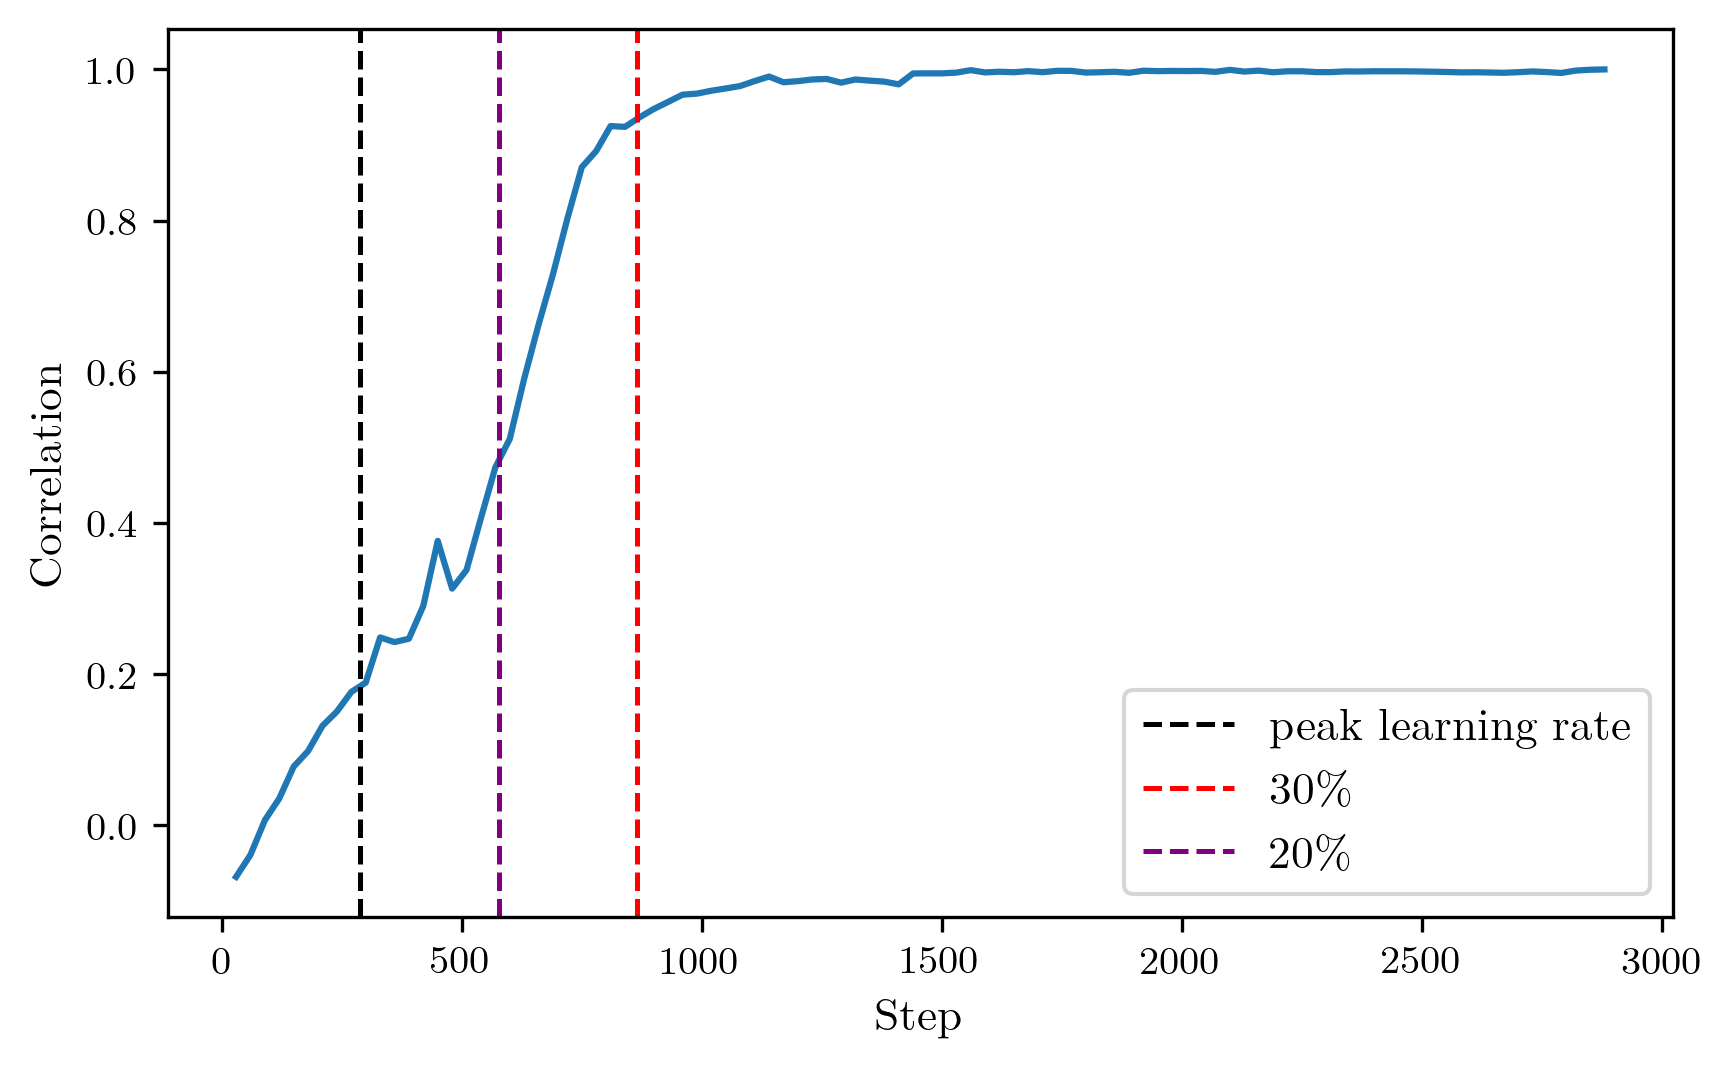

In [140]:
fig, ax = plt.subplots(figsize=big_fig)
ax.plot(steps, correlation)
ax.axvline(2886 * 0.1, color="black", linestyle="--", label="peak learning rate", linewidth=1.2)
ax.axvline(3 * 2886 * 0.1, color="red", linestyle="--", label="30\%", linewidth=1.2)
ax.axvline(2 * 2886 * 0.1, color="purple", linestyle="--", label="20\%", linewidth=1.2)
plt.xlabel("Step")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.savefig("figures/correlation.png")

In [110]:
runs_df[runs_df["step"] == 570].sort_values("value")

,step,value,final_val_loss,learning_rate
18,570,3.282799,2.046058,0.00234
18,570,4.182359,3.163644,0.01200
18,570,4.213708,2.900488,0.00100
18,570,4.282358,3.113370,0.01600
18,570,4.308964,3.129100,0.01700
...,...,...,...,...
18,570,5.471511,5.728303,0.10000
18,570,5.648661,5.606865,0.10000
18,570,7.901080,4.451725,0.00010
18,570,8.376865,4.427736,0.00010


In [111]:
runs_df

,step,value,final_val_loss,learning_rate
0,30,49.306580,4.427736,0.0001
1,60,32.919930,4.427736,0.0001
2,90,24.090265,4.427736,0.0001
3,120,19.410635,4.427736,0.0001
4,150,16.551481,4.427736,0.0001
...,...,...,...,...
91,2760,3.785069,3.380953,0.0100
92,2790,3.790125,3.380953,0.0100
93,2820,3.418545,3.380953,0.0100
94,2850,3.378344,3.380953,0.0100


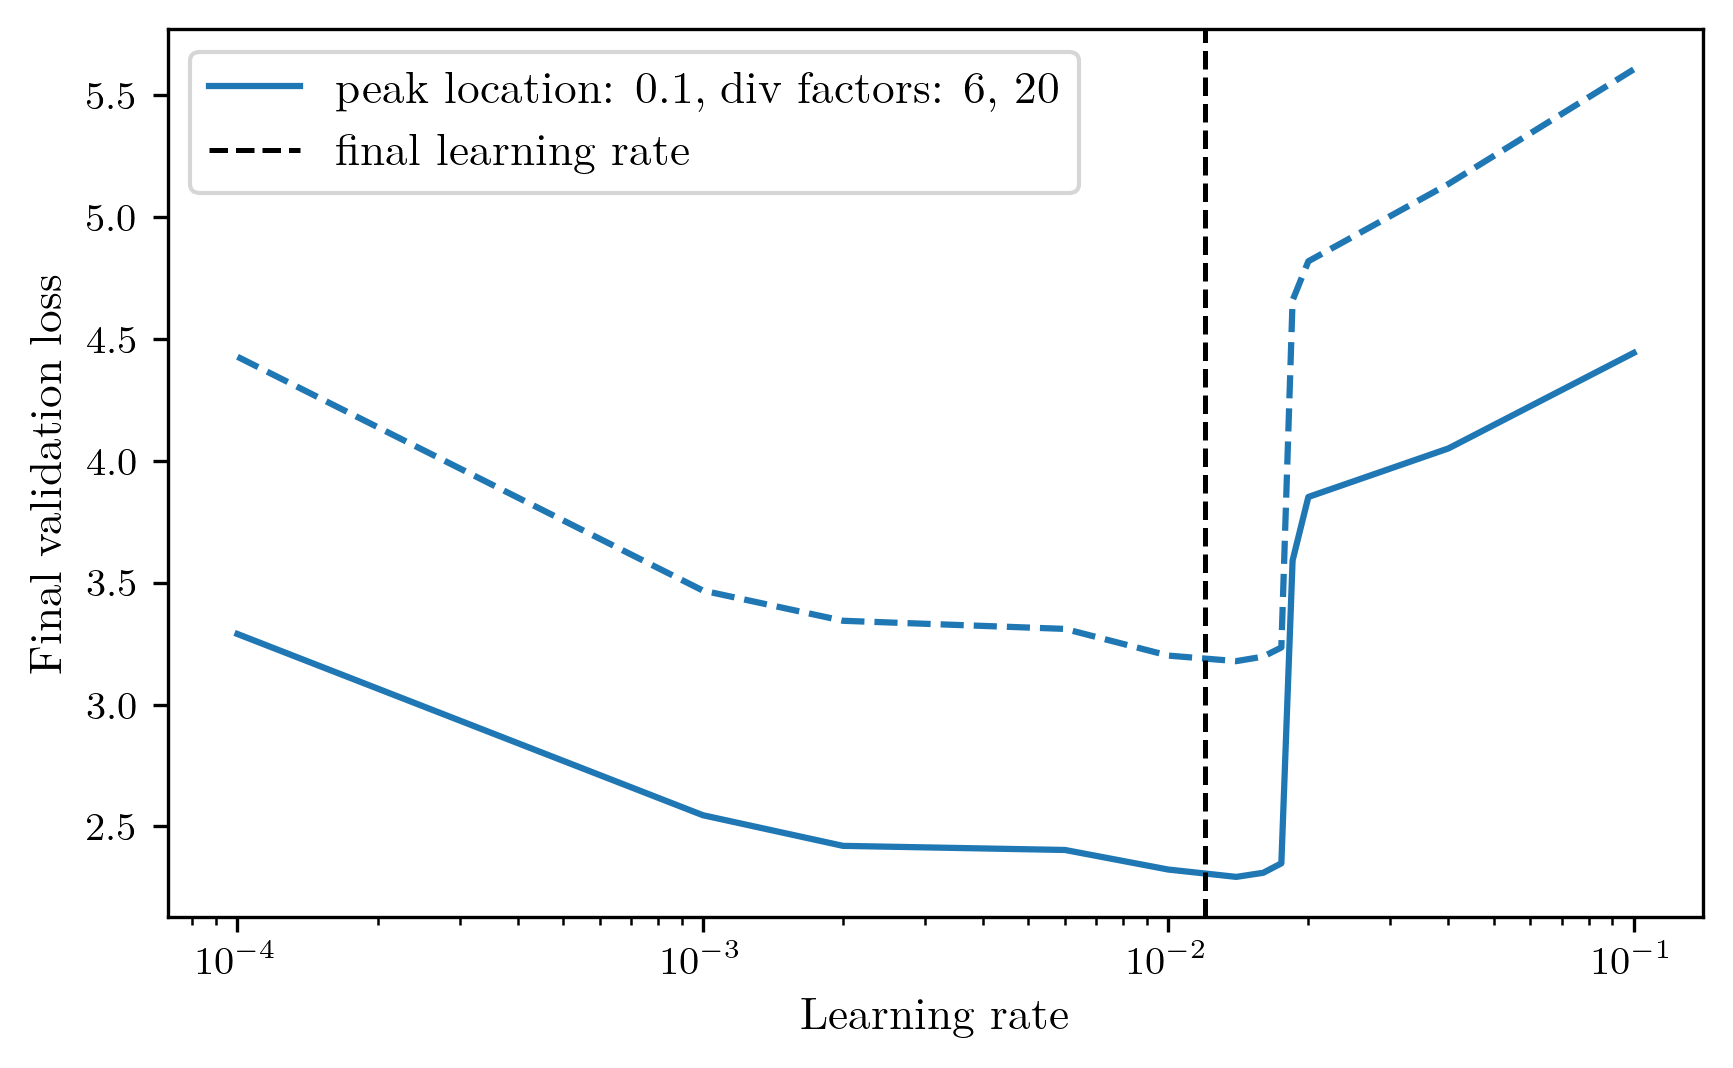

In [112]:
better_name_dict = {"learning_rate_search": "peak location: 0.3, div factors: 3, 10",
                    "learning_rate_search_reduced_pct": "peak location: 0.05, div factors: 10, 100",
                    "learning_rate_search_balanced_pct": "peak location: 0.1, div factors: 6, 20",}

fig, ax = plt.subplots(figsize=big_fig)
for exp, g in single_metrics_df.groupby("experiment"):
    if exp != "learning_rate_search_balanced_pct":
        continue
    g.sort_values("learning_rate", ascending=True, inplace=True)
    train_line, = ax.plot(g["learning_rate"], g["final_train_loss"], label=better_name_dict[exp])
    ax.plot(g["learning_rate"], g["posttraining_validation_loss"], linestyle="--", color=train_line.get_color())
    
ax.set_xscale("log")
ax.axvline(0.012, color="black", linestyle="--", label="final learning rate", linewidth=1.2)
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_rate_sweeps_lr_selected.png")

In [113]:
vocab_sizes = [8000, 6000, 4000, 2000, 3000, 1000, 15000, 20000, 10000, 12000, 9000]
val_losses = [3.480623483657837, 3.3805124759674072, 3.2450544834136963, 2.9004878997802734, 3.181204319000244, 2.046058177947998, 3.8661134243011475, 3.8762733936309814, 3.76596999, 3.832890510559082, 3.49914718]

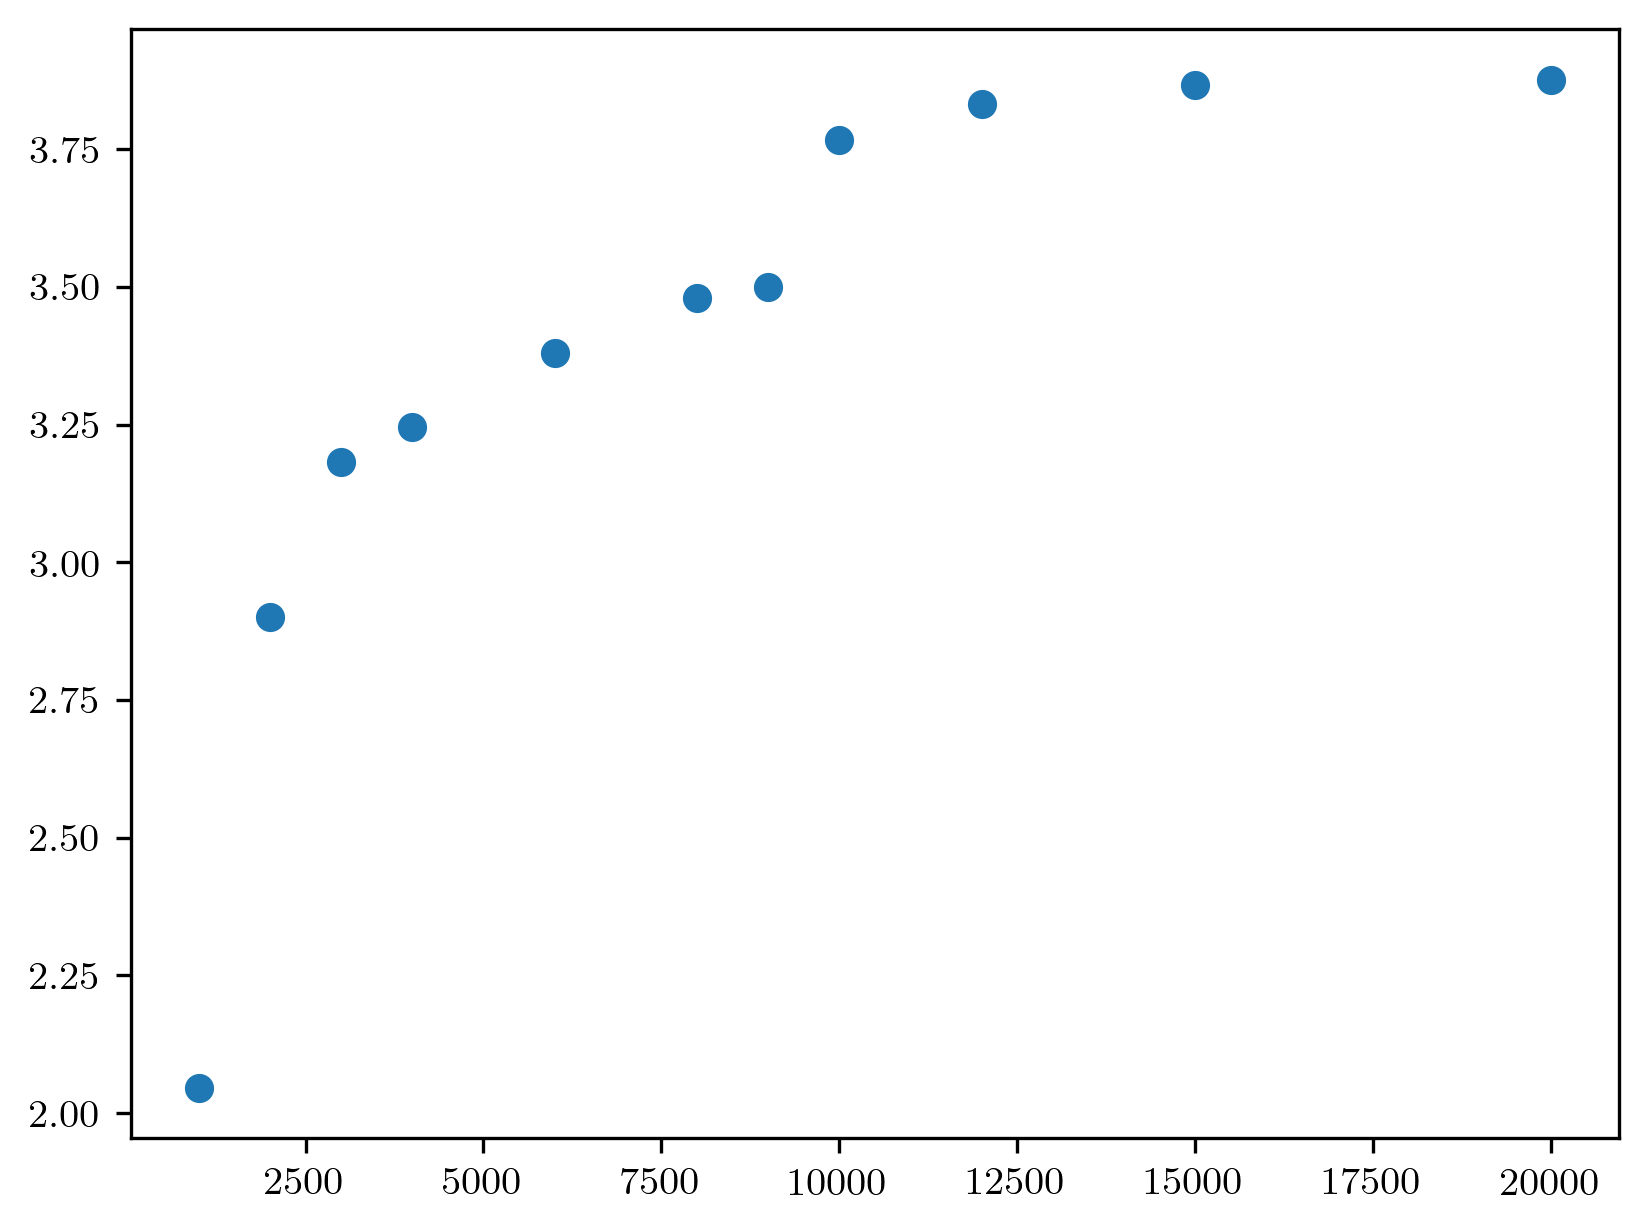

In [114]:
plt
plt.scatter(vocab_sizes, val_losses)

In [115]:
import numpy as np
np.logspace(-1, 0, 4)[:3]

array([0.1       , 0.21544347, 0.46415888])

In [116]:
# Minimal: compute bytes/token + BPB from existing val_losses
import math
from pathlib import Path
from sentencepiece import SentencePieceProcessor
from lib.data_components.datasets import _load_hf_split_cached, _interleave_holdout_split

# same validation split logic as your training config
base = _load_hf_split_cached("BabyLM-community/BabyLM-2026-Strict", "train")
val = _interleave_holdout_split(base, split="validation", every_n=10000, holdout_block_size=100)
texts = val["text"]
total_bytes = sum(len(t.encode("utf-8")) for t in texts)
bpbs = []

for v, loss in zip(vocab_sizes, val_losses):
    sp = SentencePieceProcessor(model_file=f"../data/tokenizers/baby_unigram_{v//1000}K.model")
    total_tokens = sum(len(sp.Encode(t, out_type=int)) for t in texts)
    bpt = total_bytes / total_tokens
    bpb = loss / (math.log(2) * bpt)
    bpbs.append(bpb)
    print(f"vocab={v:>5}  loss={loss:.4f}  bytes/token={bpt:.3f}  BPB={bpb:.4f}")

KeyboardInterrupt: 

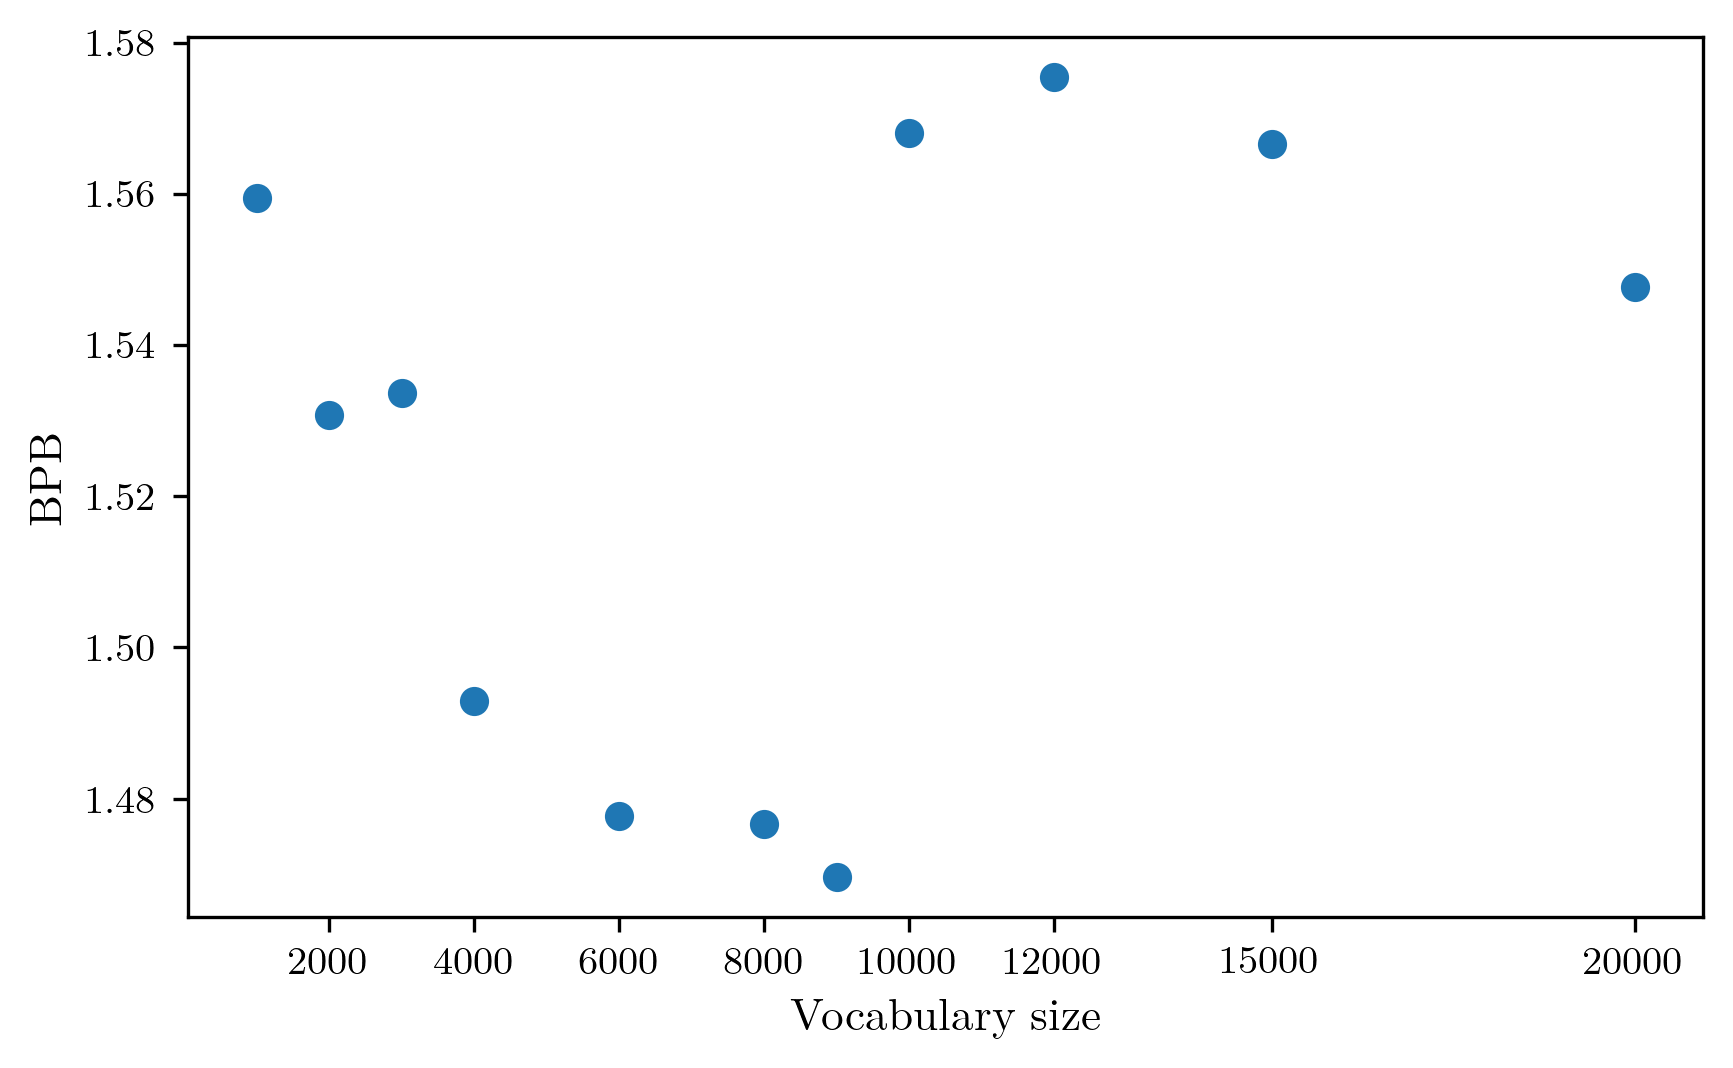

In [66]:
fig, ax = plt.subplots(figsize=big_fig)
ax.scatter(vocab_sizes, bpbs)
ax.set_xlabel("Vocabulary size")
ax.set_ylabel("BPB")
plt.xticks([2000, 4000, 6000, 8000, 10000, 12000, 15000, 20000])
plt.tight_layout()
plt.savefig("figures/vocab_sweep.png")

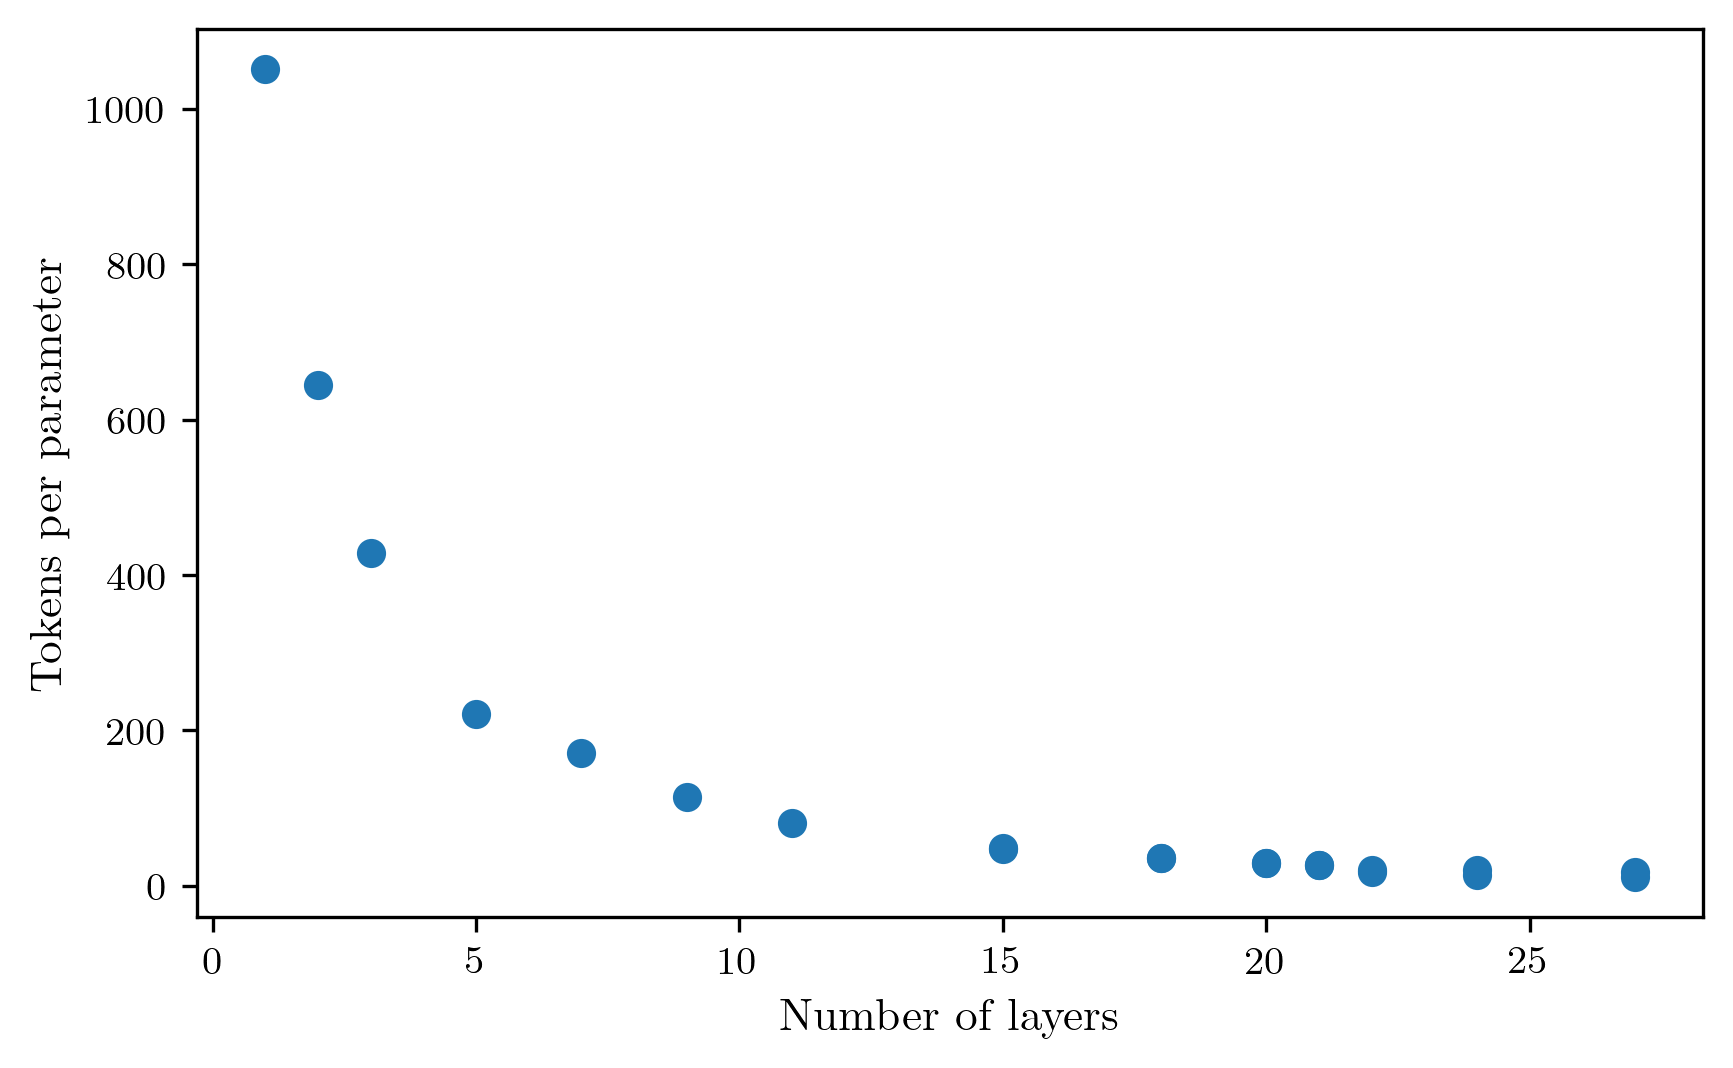

In [151]:
plot_df = single_metrics_df[single_metrics_df["experiment"] == "tokens_per_parameter_search"].dropna(subset=["num_layers", "tokens_per_parameter"])
plot_df = plot_df.drop(23) # big outlier

fig, ax = plt.subplots(figsize=big_fig)
ax.scatter(plot_df["num_layers"], plot_df["tokens_per_parameter"])
ax.set_xlabel("Number of layers")
ax.set_ylabel("Tokens per parameter")
plt.tight_layout()
plt.savefig("figures/tokens_per_parameter_vs_num_layers.png")

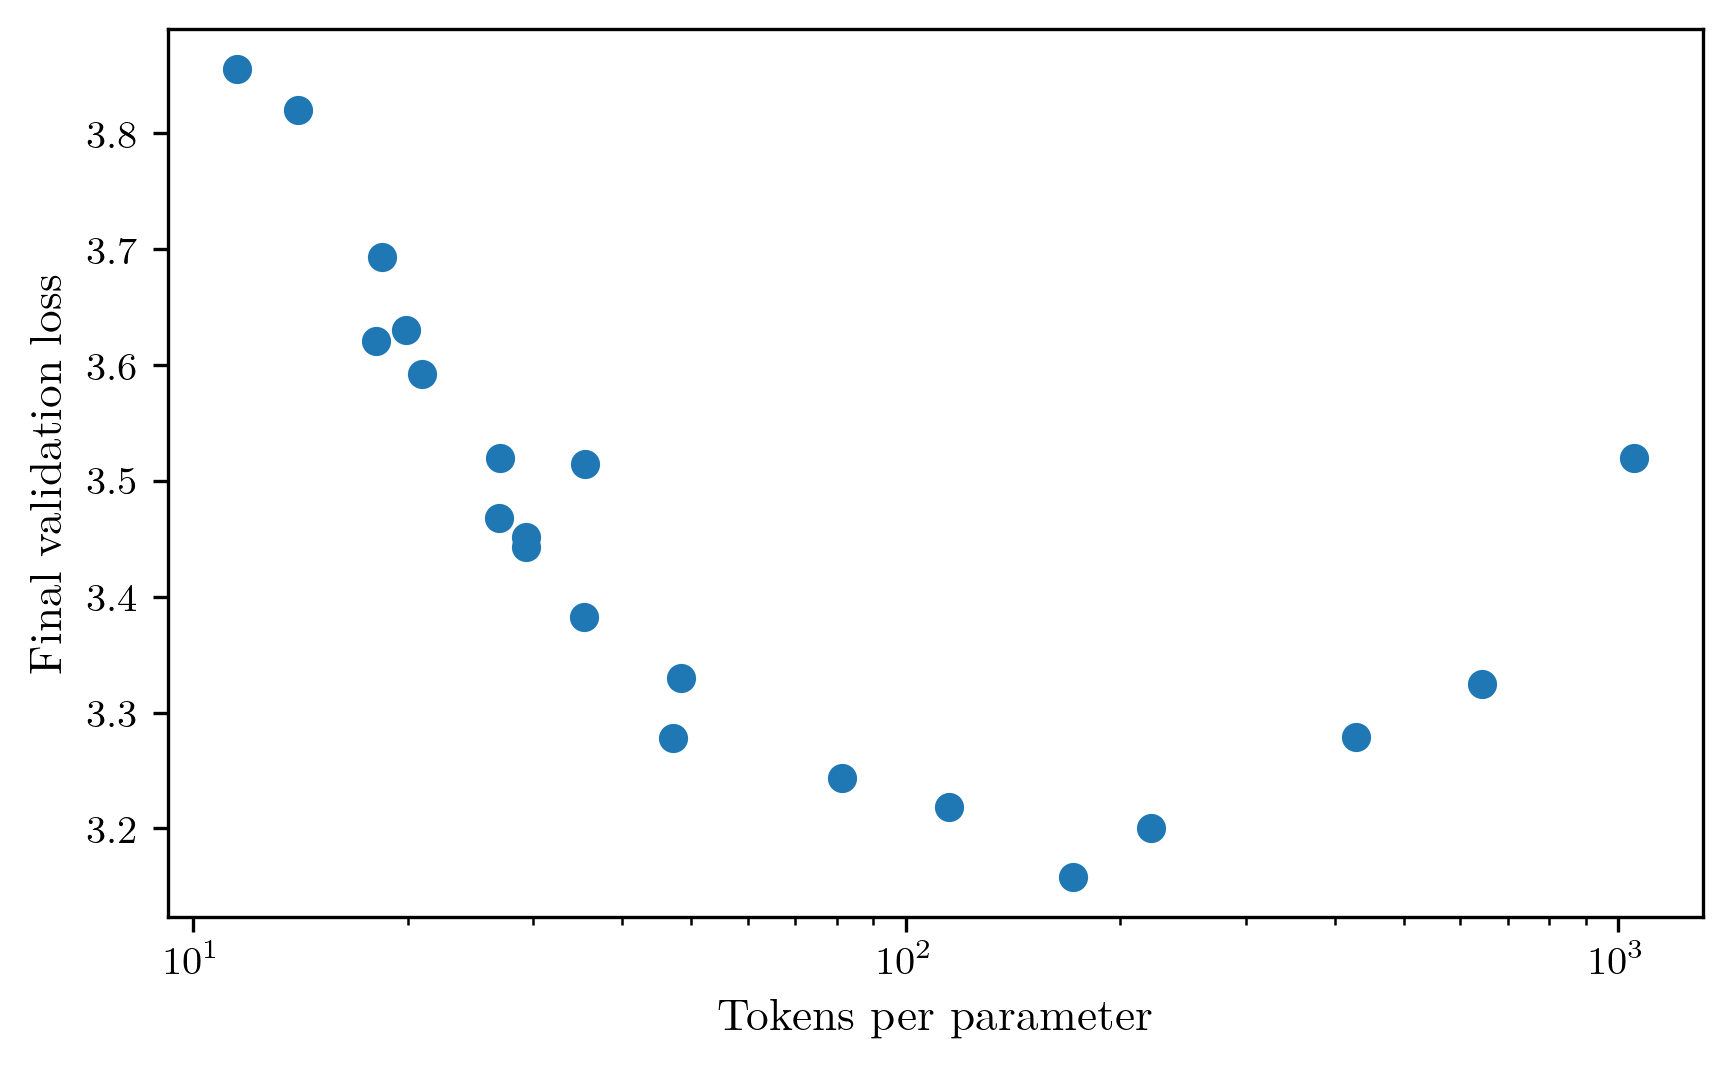

In [154]:
plot_df = single_metrics_df[single_metrics_df["experiment"] == "tokens_per_parameter_search"].dropna(subset=["tokens_per_parameter", "posttraining_validation_loss"])
plot_df = plot_df.drop(23) # big outlier

fig, ax = plt.subplots(figsize=big_fig)
ax.scatter(plot_df["tokens_per_parameter"], plot_df["posttraining_validation_loss"])
ax.set_xlabel("Tokens per parameter")
ax.set_ylabel("Final validation loss")
ax.set_xscale("log")
plt.tight_layout()
plt.savefig("figures/posttraining_validation_loss_vs_tokens_per_parameter.png")

In [157]:
np.argmin(plot_df["posttraining_validation_loss"])

np.int64(2)

In [160]:
plot_df.iloc[2]

run_hash                           13e0d594107841e592deace0
experiment                      tokens_per_parameter_search
learning_rate                                      0.007208
posttraining_validation_loss                       3.158059
tokens_per_parameter                             171.609811
num_layers                                                7
final_train_loss                                   3.445646
final_val_loss                                     3.125993
Name: 4, dtype: object